# Stage 4: Layer Normalization

## Why Normalization Matters

Deep networks have a problem: **internal covariate shift**

```
Layer 1 output: values in range [-100, 100]
Layer 2 output: values in range [-10000, 10000]  ← Exploding!
Layer 3 output: values in range [-0.0001, 0.0001] ← Vanishing!
```

This makes training unstable. **Normalization keeps values in a reasonable range.**

### Normalization Methods

| Method | Normalizes Across | Used In |
|--------|------------------|--------|
| **Batch Norm** | Batch dimension | CNNs, older models |
| **Layer Norm** | Feature dimension | Transformers |
| **RMS Norm** | Feature dimension (simplified) | LLaMA, modern LLMs |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

---
## 1. The Intuition: Standardization

Remember standardization from statistics?

$$z = \frac{x - \mu}{\sigma}$$

This transforms any distribution to have:
- **Mean = 0**
- **Standard deviation = 1**

Layer Norm does exactly this, but **per sample, across features**.

In [2]:
# Simple example: standardization
x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])

mean = x.mean()
std = x.std(unbiased=False)  # Population std

x_normalized = (x - mean) / std

print(f"Original:    {x.numpy()}")
print(f"Mean: {mean:.2f}, Std: {std:.2f}")
print(f"")
print(f"Normalized:  {x_normalized.numpy()}")
print(f"New Mean: {x_normalized.mean():.6f}, New Std: {x_normalized.std(unbiased=False):.6f}")

Original:    [1. 2. 3. 4. 5.]
Mean: 3.00, Std: 1.41

Normalized:  [-1.4142135  -0.70710677  0.          0.70710677  1.4142135 ]
New Mean: 0.000000, New Std: 1.000000


---
## 2. Batch Norm vs Layer Norm

The key difference is **which dimension we normalize across**:

```
Input shape: (Batch, Sequence, Features)
             (  B  ,    S    ,    D    )

Batch Norm:  Normalize across B (batch dimension)
             Each feature has its own mean/std computed across all samples

Layer Norm:  Normalize across D (feature dimension)  
             Each sample has its own mean/std computed across all features
```

/tmp/ipykernel_3883/49345297.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kkr/dev/project/AdvanceDeepLearning/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


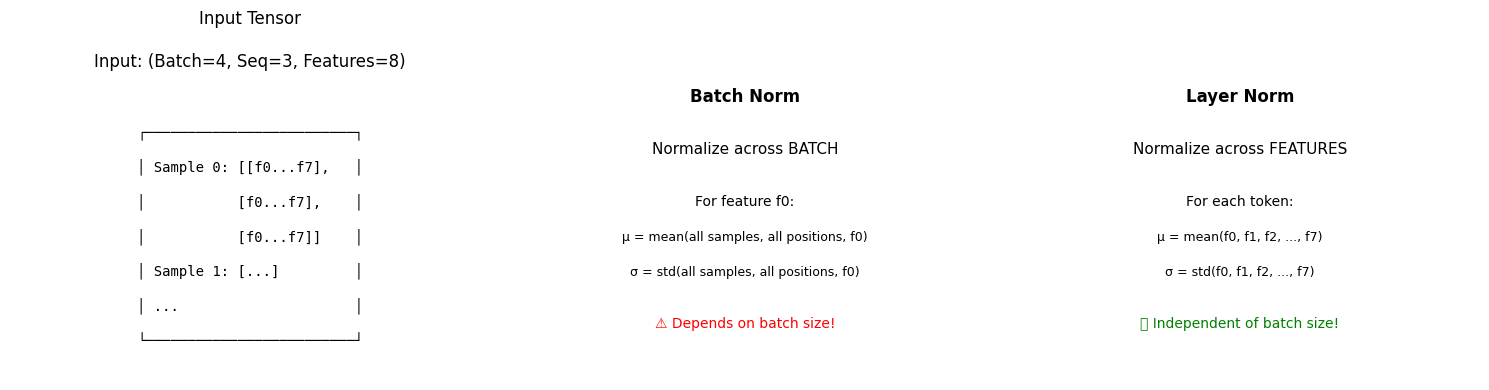

In [3]:
# Visualize the difference
batch_size, seq_len, d_model = 4, 3, 8

# Create sample tensor
x = torch.randn(batch_size, seq_len, d_model)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show the tensor structure
ax = axes[0]
ax.text(0.5, 0.9, 'Input: (Batch=4, Seq=3, Features=8)', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(0.5, 0.7, '┌─────────────────────────┐', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.6, '│ Sample 0: [[f0...f7],   │', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.5, '│           [f0...f7],    │', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.4, '│           [f0...f7]]    │', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.3, '│ Sample 1: [...]         │', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.2, '│ ...                     │', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.text(0.5, 0.1, '└─────────────────────────┘', ha='center', fontsize=10, family='monospace', transform=ax.transAxes)
ax.axis('off')
ax.set_title('Input Tensor', fontsize=12)

# Batch Norm visualization
ax = axes[1]
ax.text(0.5, 0.8, 'Batch Norm', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.65, 'Normalize across BATCH', ha='center', fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.5, 'For feature f0:', ha='center', fontsize=10, transform=ax.transAxes)
ax.text(0.5, 0.4, 'μ = mean(all samples, all positions, f0)', ha='center', fontsize=9, transform=ax.transAxes)
ax.text(0.5, 0.3, 'σ = std(all samples, all positions, f0)', ha='center', fontsize=9, transform=ax.transAxes)
ax.text(0.5, 0.15, '⚠️ Depends on batch size!', ha='center', fontsize=10, color='red', transform=ax.transAxes)
ax.axis('off')

# Layer Norm visualization  
ax = axes[2]
ax.text(0.5, 0.8, 'Layer Norm', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.65, 'Normalize across FEATURES', ha='center', fontsize=11, transform=ax.transAxes)
ax.text(0.5, 0.5, 'For each token:', ha='center', fontsize=10, transform=ax.transAxes)
ax.text(0.5, 0.4, 'μ = mean(f0, f1, f2, ..., f7)', ha='center', fontsize=9, transform=ax.transAxes)
ax.text(0.5, 0.3, 'σ = std(f0, f1, f2, ..., f7)', ha='center', fontsize=9, transform=ax.transAxes)
ax.text(0.5, 0.15, '✅ Independent of batch size!', ha='center', fontsize=10, color='green', transform=ax.transAxes)
ax.axis('off')

plt.tight_layout()
plt.show()

### Why Layer Norm for Transformers?

1. **Variable sequence lengths**: Batch Norm statistics would be weird
2. **Small batches during inference**: Batch Norm needs large batches for stable statistics
3. **Autoregressive generation**: Generate one token at a time (batch=1)

**Layer Norm works the same whether batch_size=1 or batch_size=1000!**

---
## 3. Layer Normalization Implementation

### The Formula

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

Where:
- $\mu$ = mean across features
- $\sigma^2$ = variance across features  
- $\epsilon$ = small constant for numerical stability (usually 1e-5 or 1e-6)
- $\gamma$ = learnable scale (initialized to 1)
- $\beta$ = learnable shift (initialized to 0)

In [4]:
class LayerNorm(nn.Module):
    """
    Layer Normalization
    
    Normalizes across the last dimension (features).
    Each token gets normalized independently.
    """
    
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        
        # Learnable parameters
        self.gamma = nn.Parameter(torch.ones(d_model))   # Scale
        self.beta = nn.Parameter(torch.zeros(d_model))   # Shift
        
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            Normalized x with same shape
        """
        # Compute mean and variance across last dimension (features)
        mean = x.mean(dim=-1, keepdim=True)      # (batch, seq_len, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # (batch, seq_len, 1)
        
        # Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        
        # Scale and shift
        return self.gamma * x_norm + self.beta

In [5]:
# Test our implementation
d_model = 512
layer_norm = LayerNorm(d_model)

# Create input with varying scales
x = torch.randn(2, 10, d_model) * 100  # Large values!

# Normalize
x_norm = layer_norm(x)

print("Before LayerNorm:")
print(f"  Shape: {x.shape}")
print(f"  Mean (sample 0, token 0): {x[0, 0].mean():.2f}")
print(f"  Std (sample 0, token 0):  {x[0, 0].std():.2f}")
print(f"  Range: [{x.min():.2f}, {x.max():.2f}]")

print("\nAfter LayerNorm:")
print(f"  Shape: {x_norm.shape}")
print(f"  Mean (sample 0, token 0): {x_norm[0, 0].mean():.6f}")
print(f"  Std (sample 0, token 0):  {x_norm[0, 0].std():.4f}")
print(f"  Range: [{x_norm.min():.2f}, {x_norm.max():.2f}]")

Before LayerNorm:
  Shape: torch.Size([2, 10, 512])
  Mean (sample 0, token 0): 6.52
  Std (sample 0, token 0):  100.48
  Range: [-358.85, 409.75]

After LayerNorm:
  Shape: torch.Size([2, 10, 512])
  Mean (sample 0, token 0): 0.000000
  Std (sample 0, token 0):  1.0010
  Range: [-3.55, 4.06]


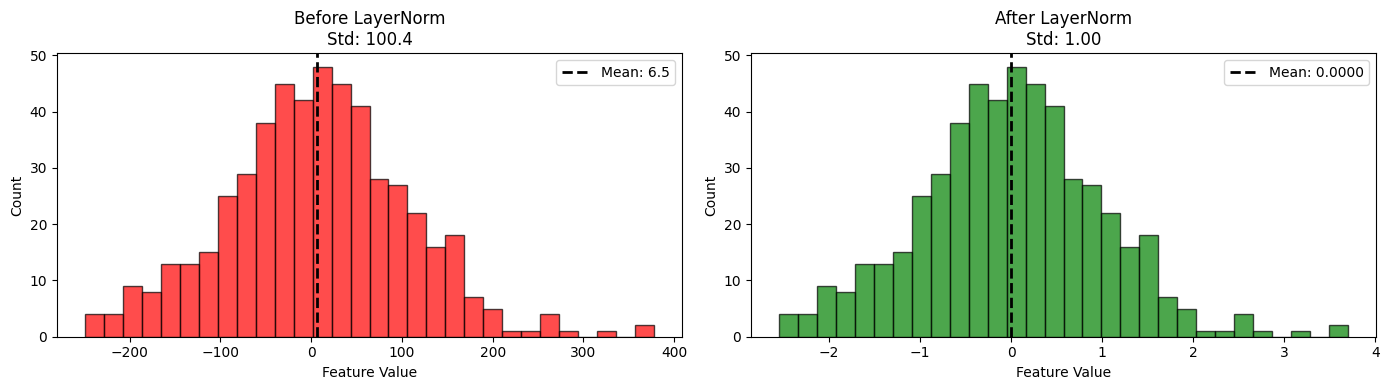

In [6]:
# Visualize the effect
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before normalization - histogram of one token
ax = axes[0]
token_before = x[0, 0].detach().numpy()
ax.hist(token_before, bins=30, alpha=0.7, color='red', edgecolor='black')
ax.axvline(x=token_before.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {token_before.mean():.1f}')
ax.set_xlabel('Feature Value')
ax.set_ylabel('Count')
ax.set_title(f'Before LayerNorm\nStd: {token_before.std():.1f}')
ax.legend()

# After normalization
ax = axes[1]
token_after = x_norm[0, 0].detach().numpy()
ax.hist(token_after, bins=30, alpha=0.7, color='green', edgecolor='black')
ax.axvline(x=token_after.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {token_after.mean():.4f}')
ax.set_xlabel('Feature Value')
ax.set_ylabel('Count')
ax.set_title(f'After LayerNorm\nStd: {token_after.std():.2f}')
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Why Learnable γ and β?

After normalization, all features have mean=0 and std=1. But maybe that's **too restrictive**!

The learnable parameters let the model:
- **γ (scale)**: "Actually, I want this feature to have larger/smaller variance"
- **β (shift)**: "Actually, I want this feature to be centered at some value, not 0"

In the extreme case: if γ=σ and β=μ, we get back the original unnormalized values!

In [7]:
# Demonstrate γ and β effect
d_model = 8
x = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]])

# Manual normalization steps
mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, keepdim=True, unbiased=False)
x_normalized = (x - mean) / torch.sqrt(var + 1e-6)

print(f"Original:   {x[0].numpy()}")
print(f"Normalized: {x_normalized[0].numpy().round(2)}")
print(f"            (mean≈0, std≈1)")

# With γ and β
gamma = torch.tensor([2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0])  # Scale by 2
beta = torch.tensor([10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0])  # Shift by 10

x_scaled = gamma * x_normalized + beta
print(f"\nWith γ=2, β=10:")
print(f"Output:     {x_scaled[0].detach().numpy().round(2)}")
print(f"            (mean≈10, std≈2)")

Original:   [1. 2. 3. 4. 5. 6. 7. 8.]
Normalized: [-1.53 -1.09 -0.65 -0.22  0.22  0.65  1.09  1.53]
            (mean≈0, std≈1)

With γ=2, β=10:
Output:     [ 6.94  7.82  8.69  9.56 10.44 11.31 12.18 13.06]
            (mean≈10, std≈2)


---
## 5. RMSNorm (Modern Alternative)

**RMSNorm** is used in LLaMA, Mistral, and most modern LLMs. It's simpler and faster!

### The Difference

```
LayerNorm: Subtract mean, divide by std
RMSNorm:   Just divide by RMS (root mean square)
```

### The Formula

$$\text{RMSNorm}(x) = \gamma \cdot \frac{x}{\sqrt{\frac{1}{n}\sum_{i=1}^{n} x_i^2 + \epsilon}}$$

Or simply:
$$\text{RMSNorm}(x) = \gamma \cdot \frac{x}{\text{RMS}(x)}$$

**Key difference: No mean subtraction, no β parameter!**

In [8]:
class RMSNorm(nn.Module):
    """
    Root Mean Square Normalization
    
    Used in LLaMA, Mistral, and modern LLMs.
    Simpler than LayerNorm: no mean centering, no beta.
    """
    
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))  # Only scale, no shift!
        
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            Normalized x with same shape
        """
        # Compute RMS (root mean square)
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        
        # Normalize and scale
        return self.gamma * (x / rms)

In [9]:
# Compare LayerNorm vs RMSNorm
d_model = 512
x = torch.randn(2, 10, d_model) * 100

ln = LayerNorm(d_model)
rms = RMSNorm(d_model)

x_ln = ln(x)
x_rms = rms(x)

print("LayerNorm:")
print(f"  Parameters: {sum(p.numel() for p in ln.parameters()):,} (gamma + beta)")
print(f"  Output mean: {x_ln[0, 0].mean():.6f}")
print(f"  Output std:  {x_ln[0, 0].std():.4f}")

print("\nRMSNorm:")
print(f"  Parameters: {sum(p.numel() for p in rms.parameters()):,} (gamma only)")
print(f"  Output mean: {x_rms[0, 0].mean():.4f}")  # Note: NOT centered!
print(f"  Output RMS:  {torch.sqrt(x_rms[0, 0].pow(2).mean()):.4f}")

LayerNorm:
  Parameters: 1,024 (gamma + beta)
  Output mean: 0.000000
  Output std:  1.0010

RMSNorm:
  Parameters: 512 (gamma only)
  Output mean: -0.1017
  Output RMS:  1.0000


In [ ]:
# Speed comparison
import time

d_model = 4096
x = torch.randn(8, 2048, d_model)

ln = LayerNorm(d_model)
rms_norm = RMSNorm(d_model)

# Warm up
_ = ln(x)
_ = rms_norm(x)

# Time LayerNorm
start = time.perf_counter()
for _ in range(100):
    _ = ln(x)
ln_time = time.perf_counter() - start

# Time RMSNorm
start = time.perf_counter()
for _ in range(100):
    _ = rms_norm(x)
rms_time = time.perf_counter() - start

print(f"LayerNorm: {ln_time*1000:.1f} ms")
print(f"RMSNorm:   {rms_time*1000:.1f} ms")
print(f"Speedup:   {ln_time/rms_time:.2f}x")

---
## 6. Pre-Norm vs Post-Norm

Where you put LayerNorm in the transformer block matters a lot!

### Original Transformer (Post-Norm)

```
x → Attention → Add(x) → LayerNorm → FFN → Add → LayerNorm → output
```

### Modern Transformers (Pre-Norm)

```
x → LayerNorm → Attention → Add(x) → LayerNorm → FFN → Add(x) → output
```

**Pre-Norm is more stable for training deep networks!**

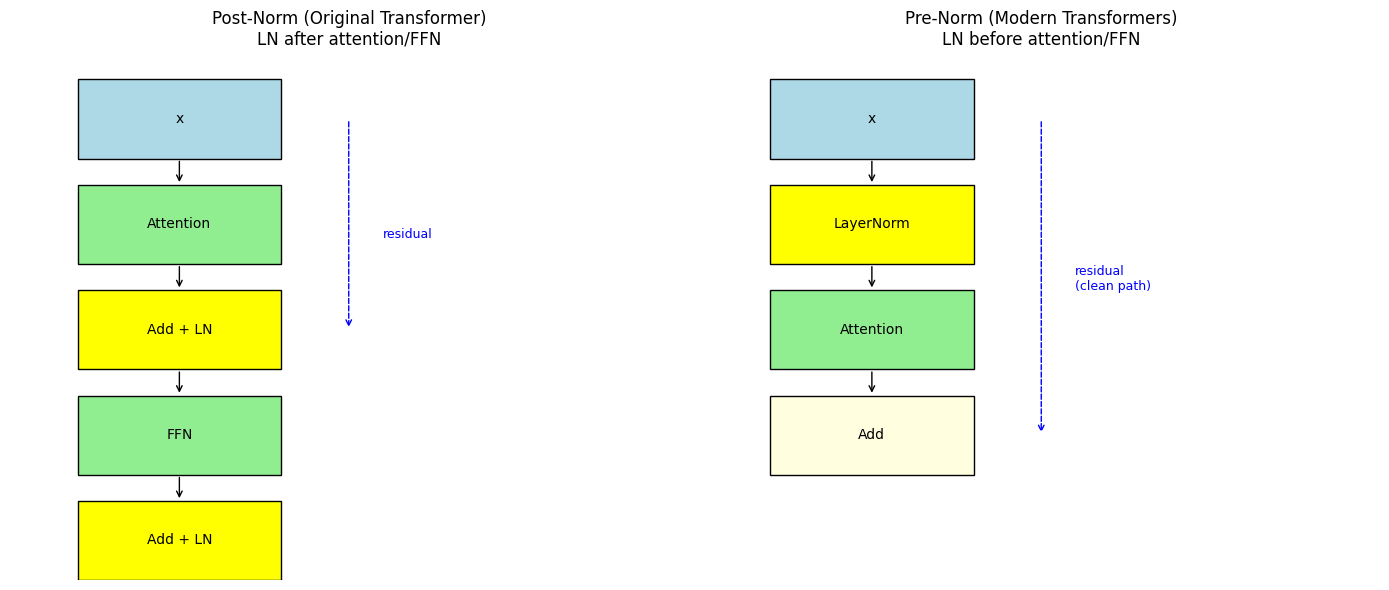

Why Pre-Norm is better:
  • Residual path is 'clean' - gradients flow directly
  • More stable for very deep networks (100+ layers)
  • Easier to train without careful learning rate tuning


In [ ]:
# Visualize Pre-Norm vs Post-Norm

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Post-Norm (Original)
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Draw the flow
boxes = [
    (1, 8, 'x', 'lightblue'),
    (1, 6, 'Attention', 'lightgreen'),
    (1, 4, 'Add + LN', 'yellow'),
    (1, 2, 'FFN', 'lightgreen'),
    (1, 0, 'Add + LN', 'yellow'),
]

for x_pos, y_pos, text, color in boxes:
    ax.add_patch(plt.Rectangle((x_pos, y_pos), 3, 1.5, facecolor=color, edgecolor='black'))
    ax.text(x_pos + 1.5, y_pos + 0.75, text, ha='center', va='center', fontsize=10)

# Arrows
for i in range(len(boxes)-1):
    ax.annotate('', xy=(2.5, boxes[i+1][1]+1.5), xytext=(2.5, boxes[i][1]),
                arrowprops=dict(arrowstyle='->', color='black'))

# Residual connection
ax.annotate('', xy=(5, 4.75), xytext=(5, 8.75),
            arrowprops=dict(arrowstyle='->', color='blue', linestyle='dashed'))
ax.text(5.5, 6.5, 'residual', fontsize=9, color='blue')

ax.set_title('Post-Norm (Original Transformer)\nLN after attention/FFN', fontsize=12)
ax.axis('off')

# Pre-Norm (Modern)
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

boxes = [
    (1, 8, 'x', 'lightblue'),
    (1, 6, 'LayerNorm', 'yellow'),
    (1, 4, 'Attention', 'lightgreen'),
    (1, 2, 'Add', 'lightyellow'),
]

for x_pos, y_pos, text, color in boxes:
    ax.add_patch(plt.Rectangle((x_pos, y_pos), 3, 1.5, facecolor=color, edgecolor='black'))
    ax.text(x_pos + 1.5, y_pos + 0.75, text, ha='center', va='center', fontsize=10)

# Arrows
for i in range(len(boxes)-1):
    ax.annotate('', xy=(2.5, boxes[i+1][1]+1.5), xytext=(2.5, boxes[i][1]),
                arrowprops=dict(arrowstyle='->', color='black'))

# Residual connection (skip LN and Attention)
ax.annotate('', xy=(5, 2.75), xytext=(5, 8.75),
            arrowprops=dict(arrowstyle='->', color='blue', linestyle='dashed'))
ax.text(5.5, 5.5, 'residual\n(clean path)', fontsize=9, color='blue')

ax.set_title('Pre-Norm (Modern Transformers)\nLN before attention/FFN', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()

print("Why Pre-Norm is better:")
print("  • Residual path is 'clean' - gradients flow directly")
print("  • More stable for very deep networks (100+ layers)")
print("  • Easier to train without careful learning rate tuning")

In [ ]:
class TransformerBlockPreNorm(nn.Module):
    """
    Pre-Norm Transformer Block (Modern style - LLaMA, GPT-3, etc.)
    
    x → LN → Attention → Add(x) → LN → FFN → Add → output
    """
    
    def __init__(self, d_model, num_heads, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        # Layer norms BEFORE attention and FFN
        self.ln1 = RMSNorm(d_model)  # Modern: use RMSNorm
        self.ln2 = RMSNorm(d_model)
        
        # Attention (simplified - just linear for demo)
        self.attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        
        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # Pre-norm: normalize THEN apply attention
        x_norm = self.ln1(x)
        attn_out, _ = self.attention(x_norm, x_norm, x_norm, attn_mask=mask)
        x = x + self.dropout(attn_out)  # Residual connection
        
        # Pre-norm: normalize THEN apply FFN
        x_norm = self.ln2(x)
        ffn_out = self.ffn(x_norm)
        x = x + ffn_out  # Residual connection
        
        return x


class TransformerBlockPostNorm(nn.Module):
    """
    Post-Norm Transformer Block (Original style)
    
    x → Attention → Add(x) → LN → FFN → Add → LN → output
    """
    
    def __init__(self, d_model, num_heads, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        # Layer norms AFTER attention and FFN
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        
        self.attention = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # Post-norm: apply attention THEN normalize
        attn_out, _ = self.attention(x, x, x, attn_mask=mask)
        x = self.ln1(x + self.dropout(attn_out))  # Add & Norm
        
        # Post-norm: apply FFN THEN normalize
        ffn_out = self.ffn(x)
        x = self.ln2(x + ffn_out)  # Add & Norm
        
        return x

In [ ]:
# Test both styles
d_model = 256
num_heads = 8

pre_norm_block = TransformerBlockPreNorm(d_model, num_heads)
post_norm_block = TransformerBlockPostNorm(d_model, num_heads)

x = torch.randn(2, 10, d_model)

out_pre = pre_norm_block(x)
out_post = post_norm_block(x)

print(f"Input shape: {x.shape}")
print(f"Pre-Norm output shape: {out_pre.shape}")
print(f"Post-Norm output shape: {out_post.shape}")

print(f"\nPre-Norm parameters: {sum(p.numel() for p in pre_norm_block.parameters()):,}")
print(f"Post-Norm parameters: {sum(p.numel() for p in post_norm_block.parameters()):,}")

Input shape: torch.Size([2, 10, 256])
Pre-Norm output shape: torch.Size([2, 10, 256])
Post-Norm output shape: torch.Size([2, 10, 256])

Pre-Norm parameters: 789,248
Post-Norm parameters: 789,760


---
## 7. Comparison Summary

In [ ]:
comparison = """
┌────────────────────────────────────────────────────────────────────────────────┐
│                        NORMALIZATION METHODS COMPARISON                        │
├─────────────┬──────────────────┬──────────────────┬────────────────────────────┤
│   Method    │     Formula      │    Parameters    │         Used In            │
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│  LayerNorm  │ γ(x-μ)/σ + β     │    2 × d_model   │ BERT, GPT-2, Original      │
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│   RMSNorm   │ γ × x/RMS(x)     │    1 × d_model   │ LLaMA, Mistral, Modern LLMs│
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│  BatchNorm  │ γ(x-μ_batch)/σ+β │    2 × features  │ CNNs (not transformers)    │
└─────────────┴──────────────────┴──────────────────┴────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────┐
│                           PRE-NORM vs POST-NORM                                │
├──────────────┬───────────────────────────────┬─────────────────────────────────┤
│    Style     │           Structure           │             Notes               │
├──────────────┼───────────────────────────────┼─────────────────────────────────┤
│  Post-Norm   │ Attn → Add → LN → FFN → LN    │ Original Transformer            │
├──────────────┼───────────────────────────────┼─────────────────────────────────┤
│  Pre-Norm    │ LN → Attn → Add → LN → FFN    │ Modern (GPT-3, LLaMA, etc.)     │
│              │                               │ More stable, easier to train    │
└──────────────┴───────────────────────────────┴─────────────────────────────────┘
"""
print(comparison)


┌────────────────────────────────────────────────────────────────────────────────┐
│                        NORMALIZATION METHODS COMPARISON                        │
├─────────────┬──────────────────┬──────────────────┬────────────────────────────┤
│   Method    │     Formula      │    Parameters    │         Used In            │
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│  LayerNorm  │ γ(x-μ)/σ + β     │    2 × d_model   │ BERT, GPT-2, Original      │
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│   RMSNorm   │ γ × x/RMS(x)     │    1 × d_model   │ LLaMA, Mistral, Modern LLMs│
├─────────────┼──────────────────┼──────────────────┼────────────────────────────┤
│  BatchNorm  │ γ(x-μ_batch)/σ+β │    2 × features  │ CNNs (not transformers)    │
└─────────────┴──────────────────┴──────────────────┴────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────┐
│ 

---
## Exercises

### Exercise 1: Verify PyTorch's LayerNorm

Compare your implementation to PyTorch's built-in `nn.LayerNorm`.

In [ ]:
# TODO: Compare your LayerNorm to nn.LayerNorm
# They should produce the same output!

d_model = 64
x = torch.randn(2, 10, d_model)

# Your implementation
my_ln = LayerNorm(d_model)

# PyTorch's implementation
pytorch_ln = nn.LayerNorm(d_model)

# Copy weights to make them equivalent
# pytorch_ln.weight.data = ???
# pytorch_ln.bias.data = ???

# Compare outputs
# out_mine = my_ln(x)
# out_pytorch = pytorch_ln(x)
# print(f"Difference: {(out_mine - out_pytorch).abs().max():.8f}")

### Exercise 2: Gradient Flow Analysis

Analyze how gradients flow through Pre-Norm vs Post-Norm architectures.

In [ ]:
# TODO: Stack multiple transformer blocks and measure gradient magnitude
# at different layers. Does Pre-Norm have more stable gradients?

def analyze_gradients(model, x, num_layers):
    """
    Pass input through model and measure gradient magnitudes per layer.
    """
    # Your implementation here
    pass

---
## Summary

### What We Learned

1. **Why Normalize**: Keep activations in a reasonable range for stable training

2. **Layer Norm**: Normalize across features (not batch), works for any batch size

3. **RMSNorm**: Simpler version (no mean centering), faster, used in modern LLMs

4. **Pre-Norm vs Post-Norm**: Pre-Norm is more stable (residual path stays clean)

### Key Formulas

```
LayerNorm:  y = γ × (x - mean) / sqrt(var + ε) + β
RMSNorm:    y = γ × x / sqrt(mean(x²) + ε)
```

### Modern LLM Recipe

```
✅ RMSNorm (not LayerNorm)
✅ Pre-Norm (not Post-Norm)
✅ Applied before attention AND before FFN
```

### Next Up: Feed-Forward Networks

Where most of the parameters live! Including SwiGLU, the activation function used in modern LLMs.